In [99]:
from typing import Annotated, Literal, Sequence, TypedDict
import json
import uuid

from langchain_core.messages import (
    AIMessage,
    BaseMessage,
    HumanMessage,
    ToolCall,
    ToolMessage,
)
from langchain_core.prompts.chat import ChatPromptTemplate
from langchain_core.runnables import RunnableConfig, RunnableLambda

from langgraph.graph import END, StateGraph
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from langgraph.checkpoint.base import empty_checkpoint

from toolbox_langchain import ToolboxTool

In [3]:
from node_helper import __is_logged_in, __get_tool_to_run, get_tools_and_model, get_confirmation_needing_tools, get_auth_tools

### State

In [4]:
class UserState(TypedDict):
    """
    State with messages for each session/user.
    """
    messages: Annotated[Sequence[BaseMessage], add_messages]

### Model

In [5]:
tools, model_runnable, insert_ticket, validate_ticket = await get_tools_and_model()

### Nodes

In [6]:
async def tool_node(state: UserState, config: RunnableConfig):
    last_message = state["messages"][-1]
    tool_messages = []

    if not hasattr(last_message, "tool_calls"):
        return {"messages": []}

    for tool_call in last_message.tool_calls:
        tool_name = tool_call["name"]
        selected_tool = next((t for t in tools if t.name == tool_name), None)

        if not selected_tool:
            output = f"Error: Tool '{tool_name}' not found."
        else:
            try:
                tool_to_run: ToolboxTool = __get_tool_to_run(selected_tool, config)
                output = await tool_to_run.ainvoke(tool_call["args"])
            except Exception as e:
                output = f"Error executing tool {tool_name}: {e}"
        tool_messages.append(
            ToolMessage(
                name=tool_to_run.name,
                content=output,
                tool_call_id=tool_call["id"],
            )
        )
    return {"messages": tool_messages}

In [7]:
async def acall_model(state: UserState, config: RunnableConfig):
    messages = state["messages"]
    res = await model_runnable.ainvoke({"messages": messages}, config)
    return {"messages": [res]}

In [8]:
def request_login_node(_: UserState):
    return {
        "messages": [
            AIMessage(
                content="This action requires you to be signed in. Please log in and then try again."
            )
        ]
    }

In [9]:
def agent_should_continue(
    state: UserState, config: RunnableConfig
) -> Literal["booking_validation", "continue", "request_login", "end"]:
    messages = state["messages"]
    last_message = messages[-1]

    if not hasattr(last_message, "tool_calls") or len(last_message.tool_calls) == 0:
        return "end"

    for tool_call in last_message.tool_calls:
        if tool_call["name"] in get_auth_tools():
            if not __is_logged_in(config):
                return "request_login"
        if tool_call["name"] in get_confirmation_needing_tools():
            if tool_call["name"] == "insert_ticket":
                return "booking_validation"
    return "continue"

In [78]:
def handle_fligh_info_format(flight_info):
    flight_info = json.loads(flight_info)

    if isinstance(flight_info, list):
        return flight_info[0] if flight_info else None

    return flight_info

In [79]:
async def booking_validation_node(state: UserState):
    messages = state["messages"]
    last_message = messages[-1]
    if hasattr(last_message, "tool_calls") and len(last_message.tool_calls) > 0:
        tool_call = last_message.tool_calls[0]
        flight_info = await validate_ticket.ainvoke(tool_call.get("args"))
        print("-------------------------------------------------")
        print("-------------------------------------------------")
        print("-------------------------------------------------")
        print(flight_info)
        print("-------------------------------------------------")
        print("-------------------------------------------------")
        print("-------------------------------------------------")
        
        flight_info = handle_fligh_info_format(flight_info)

        new_message = AIMessage(
            content="Please confirm if you would like to book the ticket.",
            tool_calls=[
                ToolCall(
                    id=str(uuid.uuid4()),
                    name=tool_call.get("name"),
                    args=flight_info,
                )
            ],
            additional_kwargs={"confirmation": True},
        )
        return {"messages": [new_message]}

In [11]:
def booking_should_continue(state: UserState) -> Literal["continue", "agent"]:
    messages = state["messages"]
    last_message = messages[-1]
    if hasattr(last_message, "tool_calls") and len(last_message.tool_calls) > 0:
        return "continue"
    return "agent"

In [12]:
async def insert_ticket_node(state: UserState, config: RunnableConfig):
    messages = state["messages"]
    last_message = messages[-1]
    if hasattr(last_message, "tool_calls") and len(last_message.tool_calls) > 0:
        tool_call = last_message.tool_calls[0]
        tool_args = tool_call.get("args")
        __insert_ticket = __get_tool_to_run(insert_ticket, config)
        output = await __insert_ticket.ainvoke(tool_args)
        human_message = HumanMessage(content="Looks good to me. Book it!")
        ai_message = AIMessage(
            content=(
                "Your flight has been successfully booked."
                if output == "null"
                else output
            )
        )
        return {"messages": [human_message, ai_message]}

### Node Names

In [80]:
AGENT_NODE = "agent"
TOOL_NODE = "tools"
BOOKING_VALIDATION_NODE = "booking_validation"
INSERT_TICKET_NODE = "insert_ticket"
REQUEST_LOGIN_NODE = "request_login"

### Define Graph

#### Add Node

In [81]:
llm_graph = StateGraph(UserState)
llm_graph.add_node(AGENT_NODE, RunnableLambda(acall_model))
llm_graph.add_node(TOOL_NODE, tool_node)
llm_graph.add_node(BOOKING_VALIDATION_NODE, RunnableLambda(booking_validation_node))
llm_graph.add_node(INSERT_TICKET_NODE, RunnableLambda(insert_ticket_node))
llm_graph.add_node(REQUEST_LOGIN_NODE, request_login_node)

In [82]:
llm_graph.set_entry_point(AGENT_NODE)

#### Add Edge

In [83]:
llm_graph.add_conditional_edges(
    AGENT_NODE,
    agent_should_continue,
    {
        "continue": TOOL_NODE,
        "booking_validation": BOOKING_VALIDATION_NODE,
        "request_login": REQUEST_LOGIN_NODE,
        "end": END,
    },
)
llm_graph.add_edge(TOOL_NODE, AGENT_NODE)
llm_graph.add_conditional_edges(
    BOOKING_VALIDATION_NODE,
    booking_should_continue,
    {"continue": INSERT_TICKET_NODE, "agent": AGENT_NODE},
)
llm_graph.add_edge(INSERT_TICKET_NODE, END)
llm_graph.add_edge(REQUEST_LOGIN_NODE, END)

#### Compile

In [100]:
checkpointer = MemorySaver()

In [101]:
langgraph_app = llm_graph.compile(
    checkpointer=checkpointer, 
    debug=True, 
    interrupt_after=["booking_validation"]
)

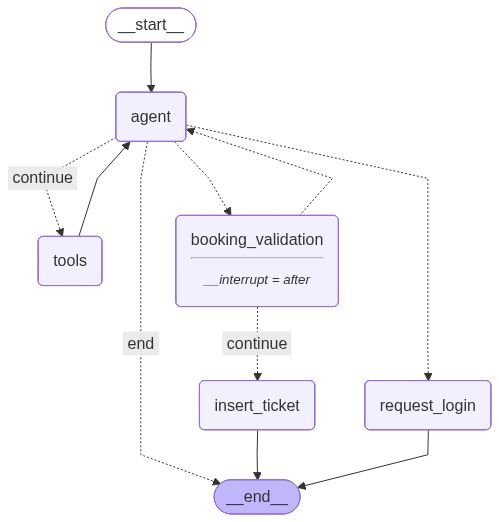

In [102]:
langgraph_app

### Invoke

In [103]:
def get_user_id_token():
    # return None
    return "simple-uid"

config = {
"configurable": {
    "thread_id": "test-id",
    "checkpoint_ns": "",
    "auth_token_getters": {
        "my_google_service": lambda: get_user_id_token()
    },
},
}

In [105]:
response = await langgraph_app.ainvoke(
    {
        "messages": HumanMessage(content="When is the next flight to Los Angeles for tomorrow?"),
    },
    config=config,
) 

[values] {'messages': [HumanMessage(content='When is the next flight to Los Angeles for tomorrow?', additional_kwargs={}, response_metadata={}, id='1350bca8-a1d3-4a33-ae56-cd6b70924fbf')]}
[updates] {'agent': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 136, 'prompt_tokens': 1326, 'total_tokens': 1462, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 83, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 256}, 'queue_time': 0.054365508, 'prompt_time': 0.092733042, 'completion_time': 0.334311069, 'total_time': 0.427044111}, 'model_provider': 'openai', 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_8a618bed98', 'id': 'chatcmpl-097c0d80-1261-4cbb-ab9e-b06d3759163c', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e55d8-4cc5-71d0-bf77-a56

In [49]:
# response = await langgraph_app.ainvoke(
#     {
#         "messages": HumanMessage(content="Can you book the ticket for the flight number #256?"),
#     },
#     config=config,
# ) 

In [110]:
response = await langgraph_app.ainvoke(
    {
        "messages": HumanMessage(content="Okey can you book the ticker for flight CY 928 then?"),
    },
    config=config,
) 

[values] {'messages': [HumanMessage(content='When is the next flight to Los Angeles for tomorrow?', additional_kwargs={}, response_metadata={}, id='1350bca8-a1d3-4a33-ae56-cd6b70924fbf'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 136, 'prompt_tokens': 1326, 'total_tokens': 1462, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 83, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 256}, 'queue_time': 0.054365508, 'prompt_time': 0.092733042, 'completion_time': 0.334311069, 'total_time': 0.427044111}, 'model_provider': 'openai', 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_8a618bed98', 'id': 'chatcmpl-097c0d80-1261-4cbb-ab9e-b06d3759163c', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e55d8-4cc5-71d0-bf77-a56cc5d1fca1-0', tool_calls=[{'name': 

In [115]:
response = await langgraph_app.ainvoke(
    None,
    config=config,
) 

[values] {'messages': [HumanMessage(content='When is the next flight to Los Angeles for tomorrow?', additional_kwargs={}, response_metadata={}, id='1350bca8-a1d3-4a33-ae56-cd6b70924fbf'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 136, 'prompt_tokens': 1326, 'total_tokens': 1462, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 83, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 256}, 'queue_time': 0.054365508, 'prompt_time': 0.092733042, 'completion_time': 0.334311069, 'total_time': 0.427044111}, 'model_provider': 'openai', 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_8a618bed98', 'id': 'chatcmpl-097c0d80-1261-4cbb-ab9e-b06d3759163c', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e55d8-4cc5-71d0-bf77-a56cc5d1fca1-0', tool_calls=[{'name': 

/home/ridwanfatur/miniconda3/envs/py3_12_9/lib/python3.12/site-packages/toolbox_core/utils.py:56: UserWarning: This connection is using HTTP. To prevent credential exposure, please ensure all communication is sent over HTTPS.
  warnings.warn(


RuntimeError: MCP request failed: {'code': -32602, 'message': 'provided parameters were invalid: error parsing authenticated parameter "user_id": missing or invalid authentication header'}

#### Observe

In [111]:
langgraph_app.get_state(
    config
).values

{'messages': [HumanMessage(content='When is the next flight to Los Angeles for tomorrow?', additional_kwargs={}, response_metadata={}, id='1350bca8-a1d3-4a33-ae56-cd6b70924fbf'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 136, 'prompt_tokens': 1326, 'total_tokens': 1462, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 83, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 256}, 'queue_time': 0.054365508, 'prompt_time': 0.092733042, 'completion_time': 0.334311069, 'total_time': 0.427044111}, 'model_provider': 'openai', 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_8a618bed98', 'id': 'chatcmpl-097c0d80-1261-4cbb-ab9e-b06d3759163c', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e55d8-4cc5-71d0-bf77-a56cc5d1fca1-0', tool_calls=[{'name': 'list_f

In [112]:
result = langgraph_app.get_state(
    config
).values

In [113]:
len(result['messages'])

7

In [114]:
print(result['messages'][-1].content)

Please confirm if you would like to book the ticket.
